# Figures for Laurianne Estrada's 2025 NAMS presentation

Prepared by: Molly Dougher

Adapted from: Xinhong Liu xliu27@nd.edu

## Imports

In [1]:
import pandas as pd
from utility import (
    loadmat,
    solve_model,
    plot_permeate_versus_interfacial_concentrations,
    plot_B_versus_interfacial_concentration,
)

future: the set contained only NumericConstant and _PythonCallbackFunctionID,
and provided no meaningful value to clients or walkers.  Users should likely
handle these types in the same manner as immutable Params.  (deprecated in
6.7.2) (called from <frozen importlib._bootstrap>:241)
'_BlockData'.  The class '_BlockData' has been renamed to 'BlockData'.
(deprecated in 6.7.2) (called from
/Users/mollydougher/opt/anaconda3/envs/dynamic-
diafiltration/lib/python3.11/site-packages/idaes/core/base/process_base.py:78)
from '_GeneralExpressionData'.  The class '_GeneralExpressionData' has been
renamed to 'ExpressionData'.  (deprecated in 6.7.2) (called from
/Users/mollydougher/opt/anaconda3/envs/dynamic-
diafiltration/lib/python3.11/site-
packages/idaes/core/base/var_like_expression.py:31)


## Load Data

NF 90 data comes from Figure 2 C-D of the DATA1 paper

NF 270 data comes from Figure 6 A-C of the DATA2 paper

In [2]:
# NF 90 (DATA1) information
data_stru90 = loadmat('DATA1_matlab/data/data_stru-dataset511.12.mat')['data_stru']
fit_stru90 = loadmat('DATA1_matlab/data/511.12 concpolar/fit_stru.mat')['fit_stru']
sim_stru90 = fit_stru90["sim_stru"]

# NF 270 (DATA2) information
data_stru270 = loadmat('data_library/data_stru-dataset270511.123.mat')['data_stru']
sim_stru270_dataframe = pd.read_json('data_library/sim_stru270_nams')
sim_stru270 = {}
for vial_num in range(data_stru270['data_config']['n']):
    vial_series = sim_stru270_dataframe[vial_num]
    sim_stru270[vial_num] = vial_series.to_dict()
data_stru270_per_vial = loadmat('data_library/data_stru-dataset270511.12.mat')['data_stru']
fit_stru270_per_vial, sim_stru270_per_vial, sim_inter270_per_vial = solve_model(data_stru270_per_vial, 'DATA', sim_opt=False, B_form='pervial')


Loading data file = DATA1_matlab/data/data_stru-dataset511.12.mat 


Loading data file = DATA1_matlab/data/511.12 concpolar/fit_stru.mat 


Loading data file = data_library/data_stru-dataset270511.123.mat 


Loading data file = data_library/data_stru-dataset270511.12.mat 

###################################################################
Creating and solving the Pyomo model with the following settings: 
mode = DATA
theta = None
sim_opt = False
B_form = pervial
 


CasADi - 2025-05-27 10:48:37 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:698]


Ipopt 3.13.2: linear_solver=ma97
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific

## Permeate Concentration Versus Interfacial Concentration

/Users/mollydougher/opt/anaconda3/envs/dynamic-diafiltration/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/mollydougher/opt/anaconda3/envs/dynamic-diafiltration/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


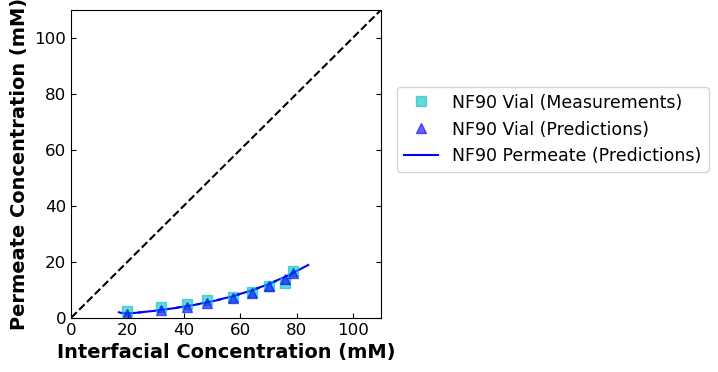

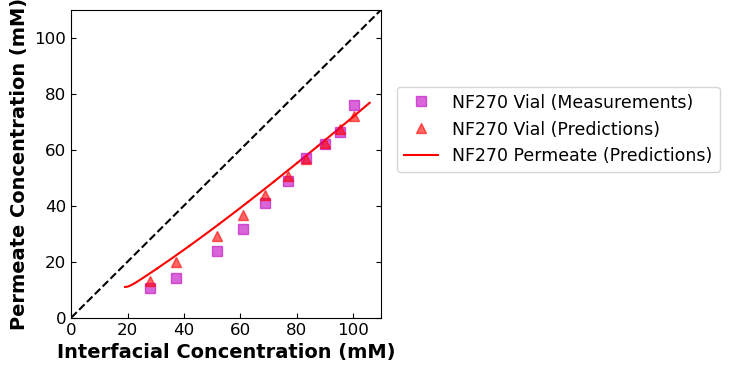

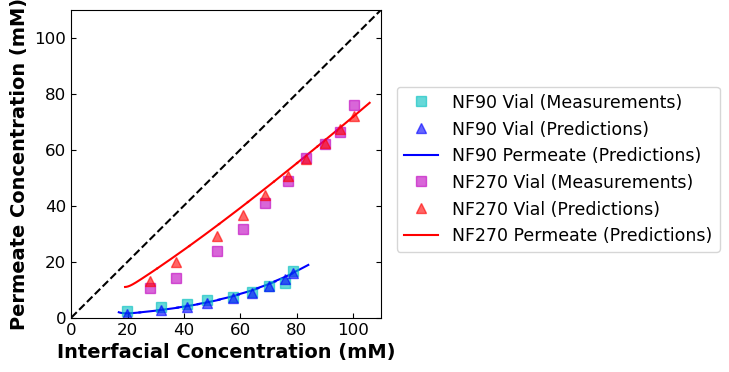

In [3]:
# NF 90 visualization
plot_permeate_versus_interfacial_concentrations(
    data_stru90,
    sim_stru90,
    DATA=1,
    lg=True,
    LOUD=False,
)
# NF 270 visualization
plot_permeate_versus_interfacial_concentrations(
    data_stru270,
    sim_stru270,
    DATA=2,
    vial_skip=3,
    lg=True,
    LOUD=False,
)
# NF 90 v NF 270 visualization
plot_permeate_versus_interfacial_concentrations(
    [data_stru90, data_stru270],
    [sim_stru90, sim_stru270],
    DATA=12,
    vial_skip=3,
    lg=True,
    LOUD=False,
)

## Solute Permeability Coefficient Versus Interfacial Concentration

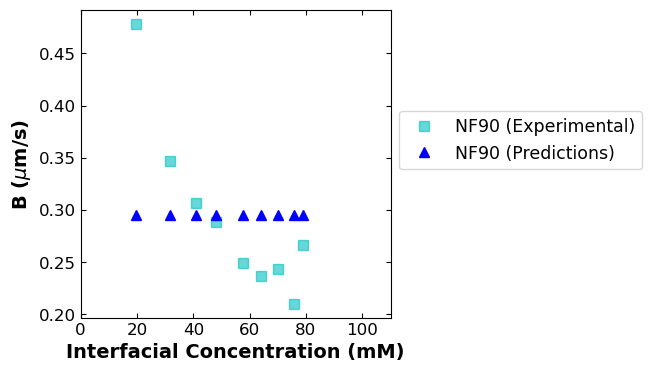

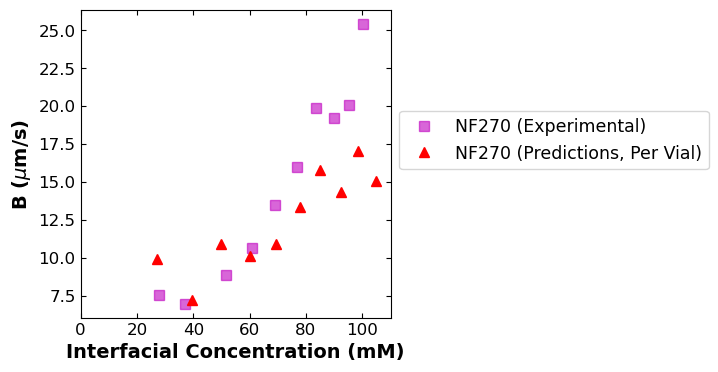

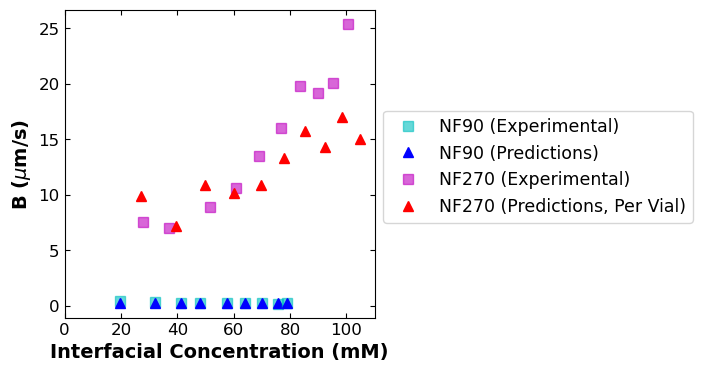

In [4]:
# NF 90 visualization
plot_B_versus_interfacial_concentration(
    data_stru90,
    DATA=1,
    lg=True,
    LOUD=False,
)
# NF 270 visualization
plot_B_versus_interfacial_concentration(
    data_stru270,
    sim_stru270_per_vial,
    DATA=2,
    vial_skip=3,
    lg=True,
    LOUD=False,
)
# NF 90 v NF 270 visualization
plot_B_versus_interfacial_concentration(
    [data_stru90, data_stru270],
    sim_stru270_per_vial,
    DATA=12,
    vial_skip=3,
    lg=True,
    LOUD=False,
)